In [2]:
%pip install textblob deep-translator pandas numpy matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   --------------------------------- ------ 524.3/624.3 kB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 2.7 MB/s  0:00:00
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
   ---


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Environment Setup and Path Configuration

This block initializes the required libraries and defines the directory structure.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from deep_translator import GoogleTranslator
from textblob import TextBlob
import os

# Visualization settings for academic standard plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Define absolute paths for reliability
RAW_DATA_PATH = r'C:\Users\SHANIA\Downloads\SOIT-Predictive-Analytics-1\data\raw_data.csv'
PROCESSED_DIR = r'../data/processed/'

# Verify directory existence
if not os.path.exists(PROCESSED_DIR):
    os.makedirs(PROCESSED_DIR)
    print(f"Created directory: {PROCESSED_DIR}")

Created directory: ../data/processed/


Schema Definition and Column Renaming

This step maps the original survey questions to short technical identifiers. This is necessary for efficient data manipulation and clear labeling in technical charts.

In [4]:
# Load dataset
df = pd.read_csv(RAW_DATA_PATH)

# Intentional Schema Mapping (Slugification)
column_mapping = {
    'Timestamp': 'timestamp',
    'Year Level': 'year_level',
    'Program': 'program',
    'Mode of Study': 'mode_of_study',
    'Quality of teaching by SOIT faculty': 'acad_qual_teaching',
    'Faculty knowledge of subject matter': 'acad_faculty_knowledge',
    'Availability of instructors for consultation': 'acad_consultation_avail',
    'Fairness of grading and assessments': 'acad_grading_fairness',
    'Availability of IT support when technical assistance is needed ': 'it_support_avail',
    'Timeliness of IT staff response to reported issues': 'it_response_time',
    'Effectiveness of IT support in resolving technical problems': 'it_problem_resolution',
    'Reliability of IT systems (Wi-Fi, portals, LMS, software platforms)': 'it_sys_reliability',
    'Classroom and laboratory facilities': 'fac_classrooms',
    'Availability and condition of computers/equipment': 'fac_equipment',
    'Internet and network reliability': 'fac_network_reliability',
    'Access to learning materials (LMS, library, software tools)': 'fac_learning_materials',
    'Availability of health services when needed': 'serv_health_avail',
    'Quality and timeliness of health service provision': 'serv_health_quality',
    'Helpfulness and accuracy of information provided by front office staff': 'serv_front_office_help',
    'Efficiency of processing requests and transactions': 'serv_admin_efficiency',
    'Convenience of office hours and procedures': 'serv_office_convenience',
    'Academic advising and guidance services': 'serv_advising',
    'Responsiveness of SOIT staff to student concerns': 'serv_staff_responsiveness',
    'Effectiveness in handling student concerns and complaints': 'serv_complaint_handling',
    'Career guidance and internship support': 'serv_career_support',
    'Availability of computers for student use in the library': 'lib_comp_avail',
    'Availability of required books and reference materials': 'lib_materials',
    'Helpfulness and approachability of library staff': 'lib_staff_help',
    'Condition and functionality of library computers': 'lib_comp_condition',
    'Availability and comfort of library spaces and seating': 'lib_spaces',
    'Cleanliness and sanitation of bathroom facilities': 'fac_bath_clean',
    'Availability of toiletries (soap, tissue, etc.)': 'fac_toiletries',
    'Availability and reliability of water supply (working faucets, bidets, etc.)': 'fac_water_supply',
    'Overall satisfaction with SOIT services': 'target_satisfaction',
    'SOIT services meet my academic needs': 'needs_alignment',
    'I would recommend SOIT to other students': 'recommendation_intent',
    'Which service do you find most helpful?': 'text_most_helpful',
    'What areas need improvement?': 'text_improvement_areas',
    'Additional comments or suggestions:': 'text_comments'
}

df.rename(columns=column_mapping, inplace=True)

def extract_sentiment(text):
    """Translates text and returns sentiment polarity score."""
    if pd.isna(text) or text.lower().strip() in ['none', 'wala naman', 'n/a']:
        return 0.0
    try:
        translated = GoogleTranslator(source='auto', target='en').translate(text)
        return TextBlob(translated).sentiment.polarity
    except:
        return 0.0

print("Processing Sentiment Analysis feature...")
df['sentiment_score'] = df['text_comments'].apply(extract_sentiment)
print("Transformation Complete.")

Processing Sentiment Analysis feature...
Transformation Complete.


Multimodal Feature Extraction

This block processes the qualitative text data. It translates regional languages to English and calculates a sentiment polarity score. This score serves as a new numerical feature for the predictive model.

In [5]:
def process_text_sentiment(text):
    """
    Translates input text to English and calculates sentiment polarity.
    Returns a float between -1.0 (negative) and 1.0 (positive).
    """
    if pd.isna(text) or text.lower().strip() in ['none', 'wala naman', 'n/a', 'diko po alam']:
        return 0.0
    
    try:
        # Standardize language to English for sentiment consistency
        translated_text = GoogleTranslator(source='auto', target='en').translate(text)
        # Calculate polarity score
        return TextBlob(translated_text).sentiment.polarity
    except Exception as e:
        return 0.0

print("Calculating sentiment scores for qualitative feedback...")
df['sentiment_score'] = df['text_comments'].apply(process_text_sentiment)
print("Sentiment feature engineering complete.")

Calculating sentiment scores for qualitative feedback...
Sentiment feature engineering complete.


Target Variable Distribution Analysis

This visualization identifies class imbalance in the target variable, which determines the requirement for data augmentation in the subsequent phase.

C:\Users\SHANIA\AppData\Local\Temp\ipykernel_13628\3137198362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_satisfaction', data=df, palette='viridis')


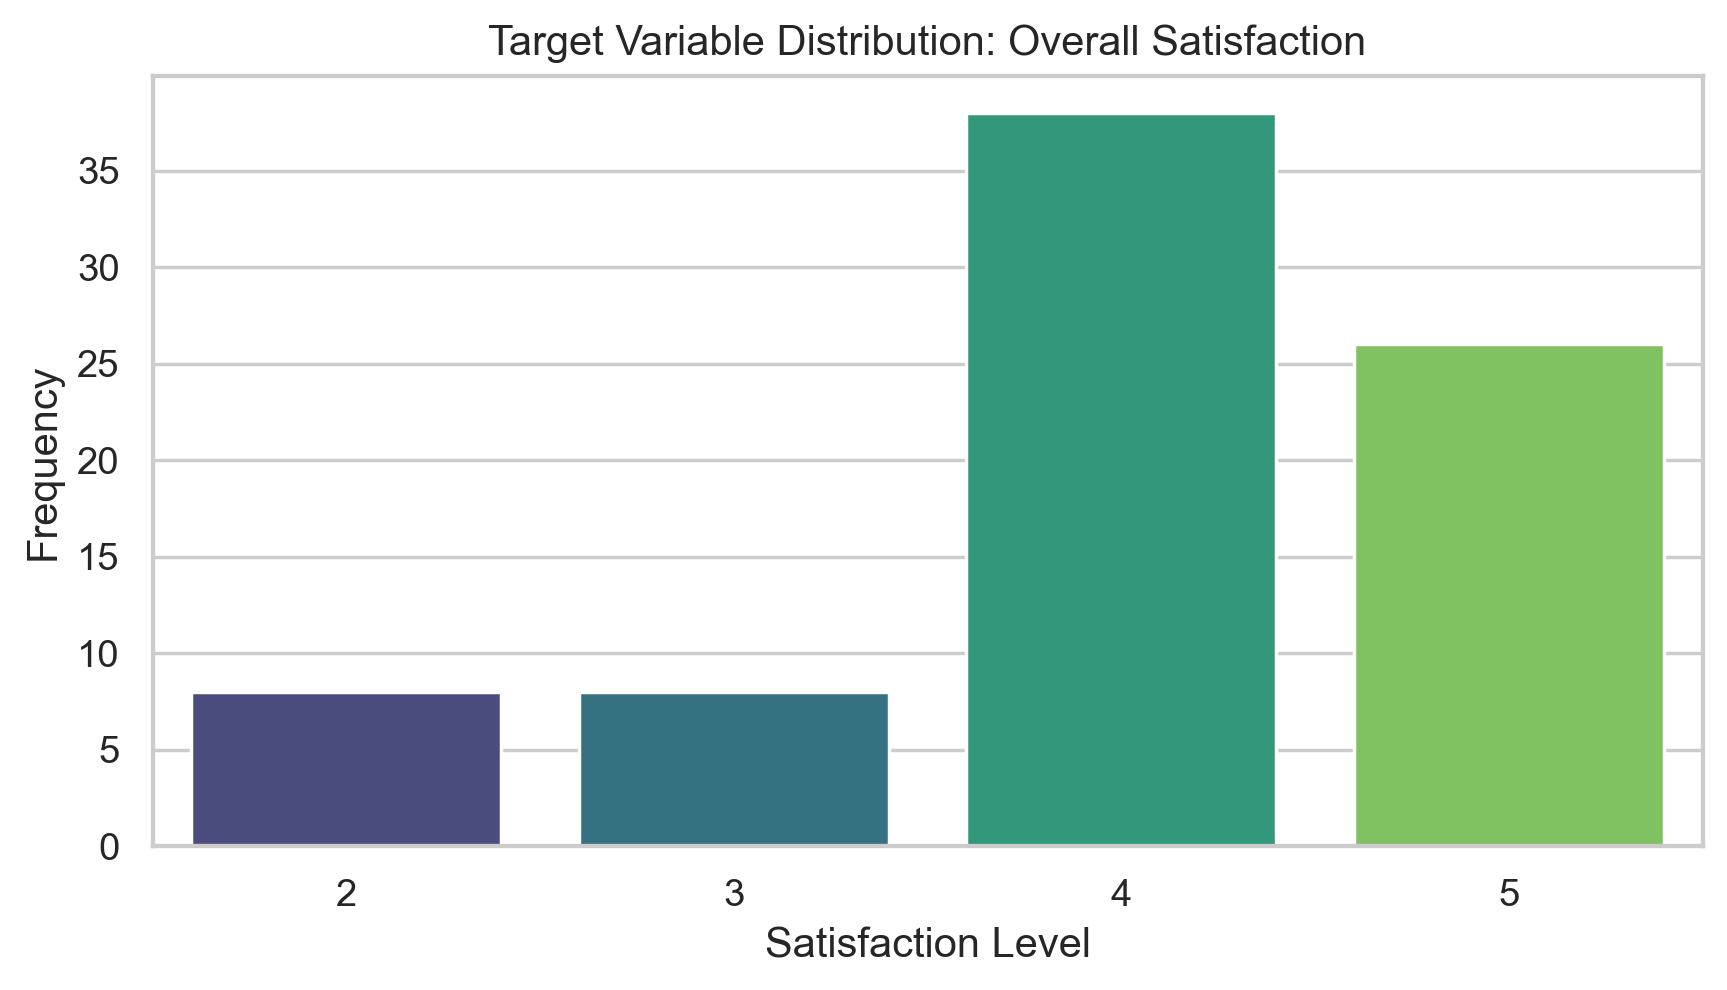

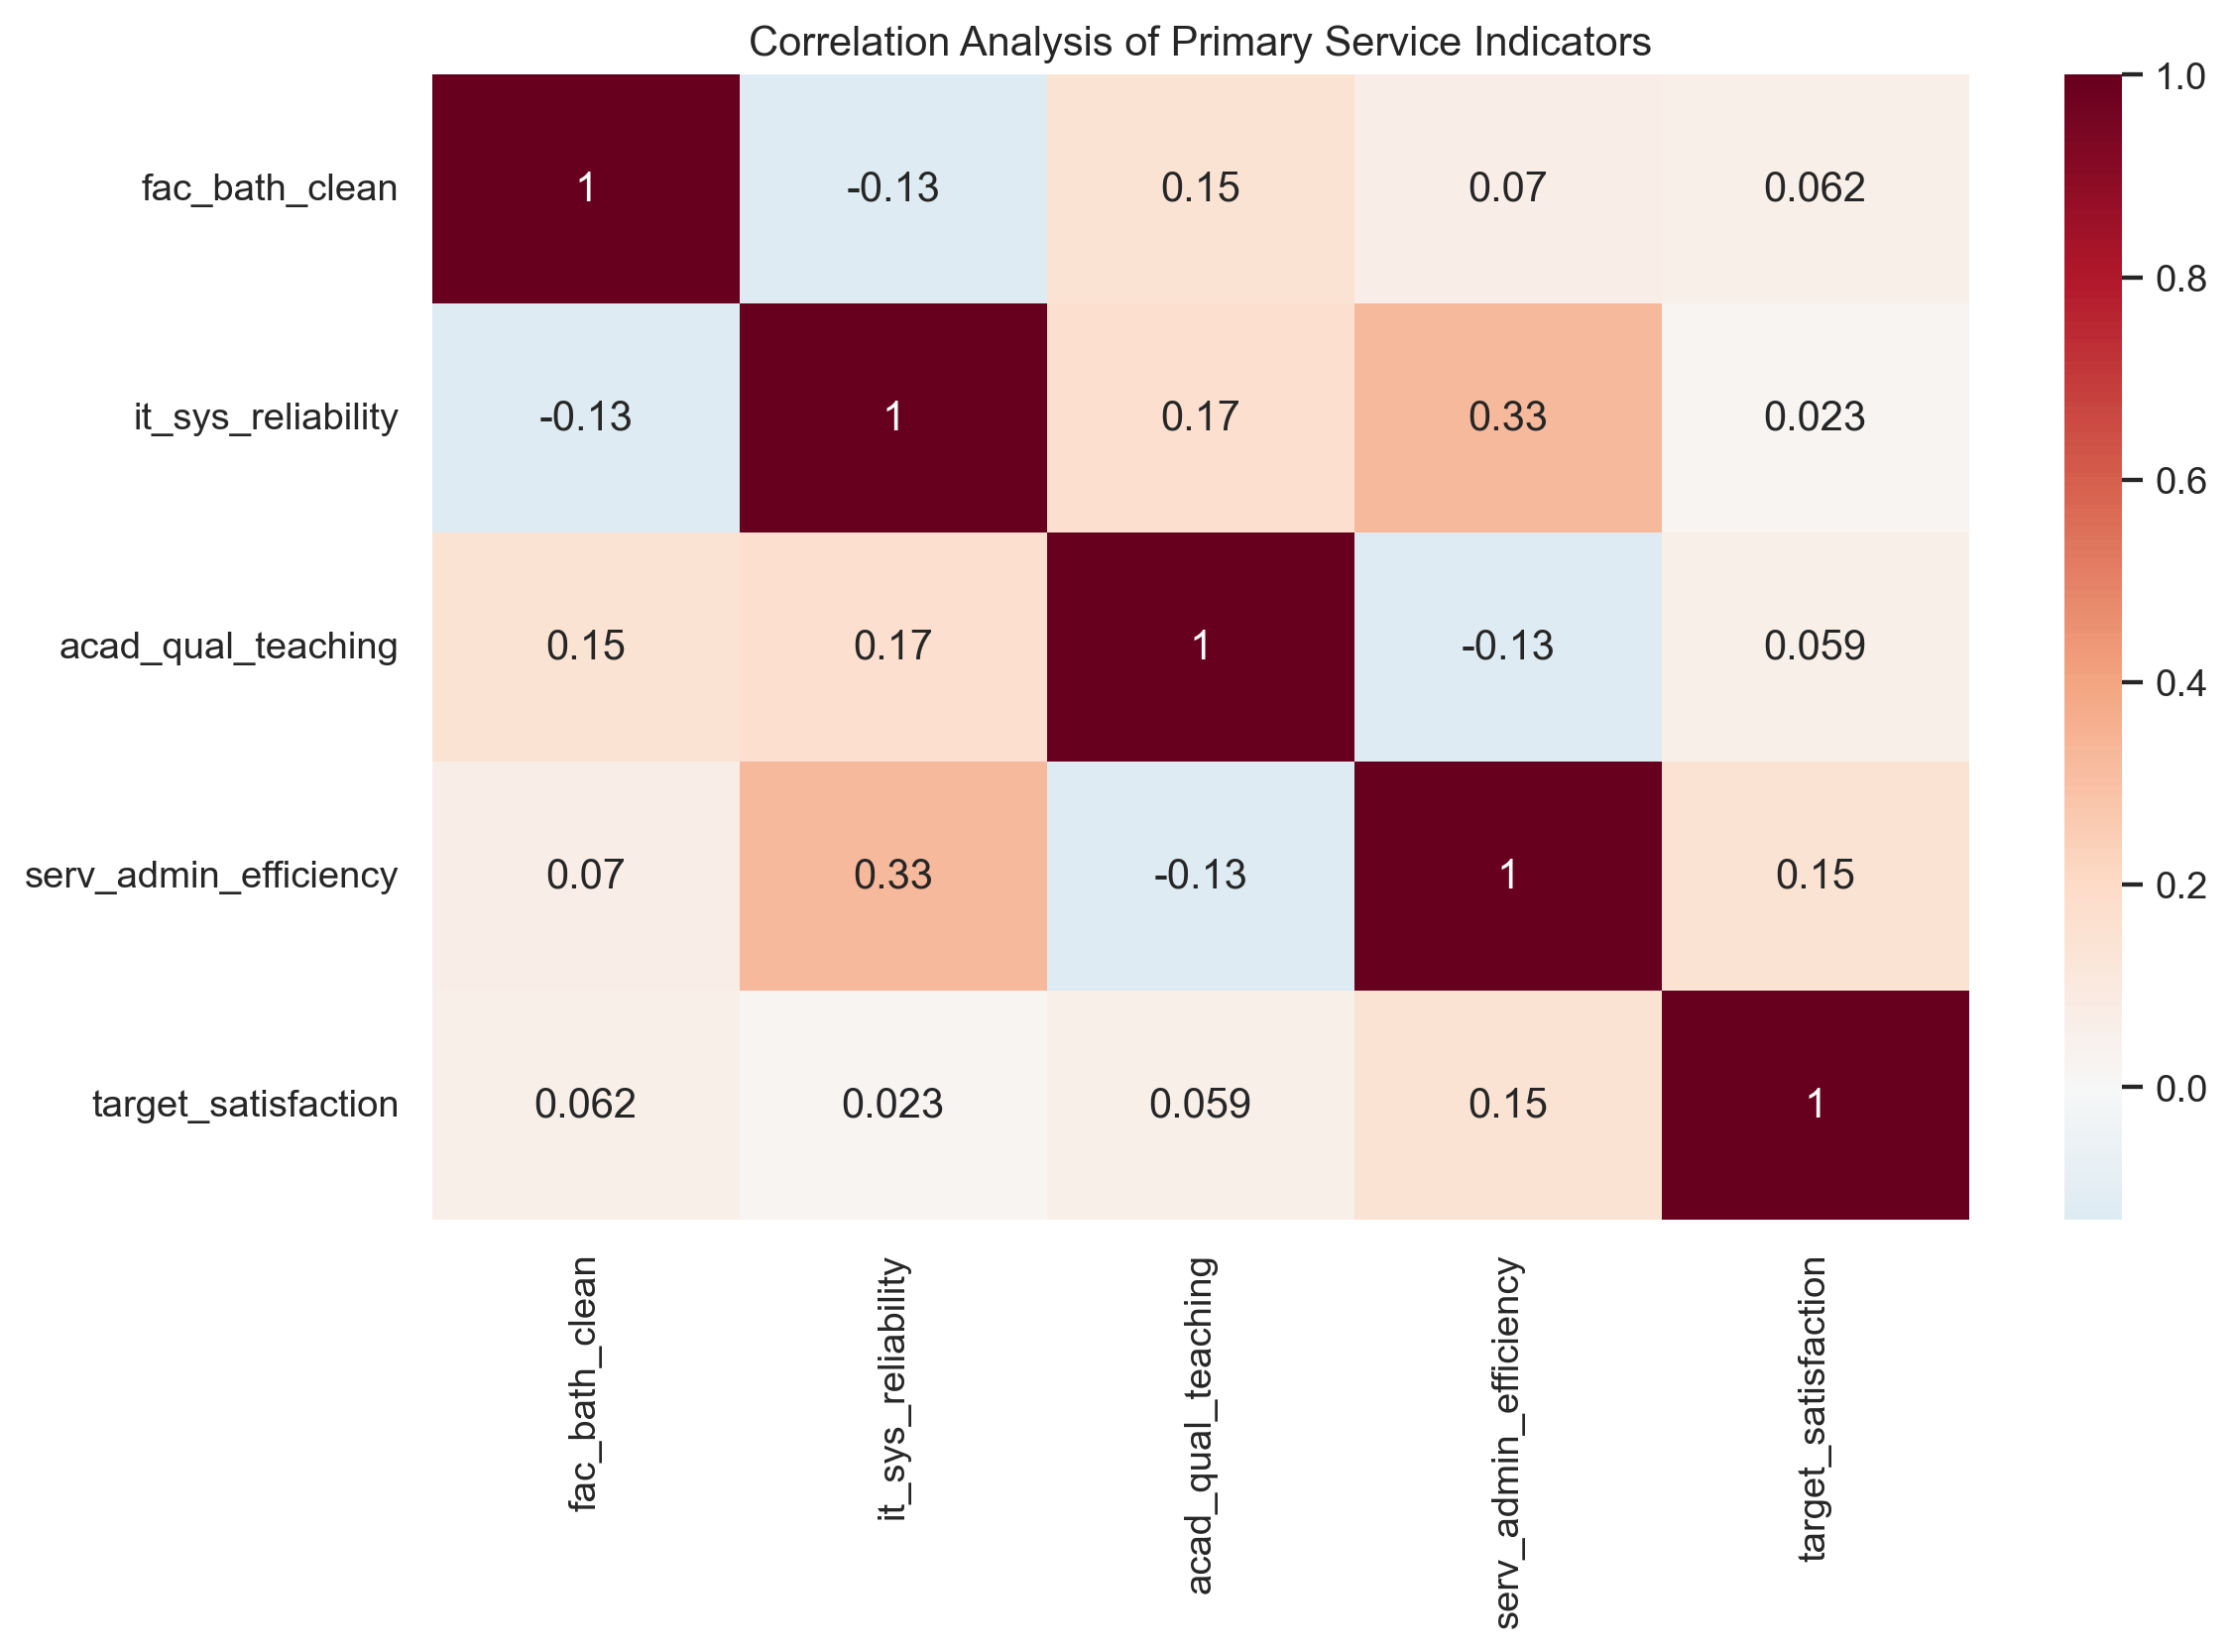

In [8]:
# Analyze the distribution of the target variable
plt.figure(figsize=(8, 4), dpi=250)
sns.countplot(x='target_satisfaction', data=df, palette='viridis')
plt.title('Target Variable Distribution: Overall Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Frequency')
plt.show()

# Observe correlation between service indicators and target satisfaction
correlation_subset = [
    'fac_bath_clean', 'it_sys_reliability', 'acad_qual_teaching', 
    'serv_admin_efficiency', 'target_satisfaction'
]
plt.figure(figsize=(10, 6), dpi=250)
sns.heatmap(df[correlation_subset].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Analysis of Primary Service Indicators')
plt.show()

Final Dataset Preparation and Export

This block removes non-numerical columns and saves the final cleaned dataset for use in the machine learning pipeline.

In [7]:
# Remove non-predictive text columns and high-cardinality metadata
df_cleaned = df.drop(columns=[
    'timestamp', 'text_most_helpful', 'text_improvement_areas', 'text_comments'
])

# Export cleaned data to the processed folder
output_filename = 'cleaned_data.csv'
output_path = os.path.join(PROCESSED_DIR, output_filename)
df_cleaned.to_csv(output_path, index=False)

print(f"Data preparation complete. Output saved to {output_path}")

Data preparation complete. Output saved to ../data/processed/cleaned_data.csv


**Technical Rationale**

1. **Column Slugification:** Standardizes features for the XGBoost model and ensures legible axis labels for SHAP explainability plots.

2. **Sentiment Quantification:** Uses natural language processing to integrate qualitative student concerns as a weighted numerical feature.

3. **Distribution Visualization:** Provides a mathematical justification for data augmentation. If the sample size is low and the distribution is skewed, the model will fail to generalize without synthetic expansion.